# Escalonamento das variáveis quantitativas (Anexo A.1)

Este notebook gera as figuras da seção **A.1.1**, aplica as equações de escalonamento publicadas na seção **A.1.4** do documento e
reproduz as estatísticas calculadas sobre a base analítica que aparecem nas seções **A.1.2**,
**A.1.3** e **A.1.4**. Cada seção numerada aqui corresponde a um ponto citado no documento, para que
o número publicado possa ser rastreado até a célula que o produziu.

Fica de fora, por pertencer a outra etapa, o que se calcula antes de a base analítica existir: a
concatenação das quatro fontes e a deduplicação que leva de 484.916 a 484.915 registros são
responsabilidade de `notebooks/pre-processamento.ipynb`, e aqui apenas se confirma o resultado.

As três variáveis tratadas são `TEMPO_VOO`, `ATRASO_CHEGADA` e `QTDE_VIAGENS_12M`.

**Base de entrada.** O notebook lê `data/processed/base_analitica.parquet`, gerado por
`notebooks/pre-processamento.ipynb`. A pasta `data/` não é versionada, por compromisso entre o
Inteli e o parceiro, então o arquivo precisa existir localmente antes da execução. Se ele não for
encontrado, o notebook reconstrói a base a partir de `data/raw` usando `scripts/preprocessamento_nps.py`.
A contagem de 484.915 registros é verificada por `assert`, para que uma base diferente interrompa a
execução em vez de produzir números plausíveis e errados.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

# A raiz do projeto e' descoberta uma vez, e todos os caminhos derivam dela: assim o
# fallback procura os brutos no mesmo lugar em que o parquet foi procurado, seja o
# notebook executado da raiz do repositorio, de dentro de notebooks/ ou do Colab.
RAIZ = next(
    (c for c in [Path('.'), Path('..'), Path('/content')] if (c / 'data').exists() or (c / 'scripts').exists()),
    Path('.'),
)

caminho_base = RAIZ / 'data' / 'processed' / 'base_analitica.parquet'

if caminho_base.exists():
    df = pd.read_parquet(caminho_base)
else:
    sys.path.insert(0, str((RAIZ / 'scripts').resolve()))
    from preprocessamento_nps import integrar_bases, preparar_base_analitica

    df_bruto, _ = integrar_bases(RAIZ / 'data' / 'raw')
    df = preparar_base_analitica(df_bruto)

VARIAVEIS = ['TEMPO_VOO', 'ATRASO_CHEGADA', 'QTDE_VIAGENS_12M']

# A base errada produziria numeros plausiveis e silenciosamente diferentes dos publicados.
assert len(df) == 484915, f'a base analítica deveria ter 484.915 registros e tem {len(df)}'

print('Registros na base analítica:', f'{len(df):,}'.replace(',', '.'))

Registros na base analítica: 484.915


## 0. Teste de normalidade (seção A.1.1, item c)

Reproduz a tabela do item (c) da seção A.1.1. O teste é o de Jarque–Bera (Jarque & Bera, 1987),
implementado com `numpy` puro, sem `scipy`, exatamente como publicado no documento: a estatística
combina assimetria e curtose e, sob H0, segue qui-quadrado com dois graus de liberdade, cuja
função de sobrevivência para dois graus tem a forma fechada `exp(-JB / 2)`.

O teste roda sobre uma amostra aleatória de 2.000 observações por variável, com `random_state=42`,
e não sobre a base inteira: com 484.915 registros o teste tem poder para rejeitar H0 diante de
desvios sem relevância prática. A amostragem é o que torna a decisão informativa, e não uma
formalidade.

Os p-valores sofrem *underflow* e retornam `0.0`, por isso o documento os reporta como
menores que 0,001.


In [2]:
def jarque_bera_manual(dados):
    """Jarque-Bera com numpy puro, sem scipy.

    O p-valor usa a forma fechada da sobrevivencia da qui-quadrado com dois graus
    de liberdade, exp(-JB / 2), valida apenas para gl = 2, que e o caso do teste.
    """
    dados = np.asarray(dados, dtype=float)
    n = len(dados)
    media = dados.mean()
    desvio = dados.std(ddof=0)
    skew = np.mean(((dados - media) / desvio) ** 3)
    kurt = np.mean(((dados - media) / desvio) ** 4)
    jb = (n / 6) * (skew**2 + ((kurt - 3) ** 2) / 4)
    return jb, np.exp(-jb / 2)


ALFA = 0.05
TAMANHO_AMOSTRA = 2000

linhas = []
for coluna in VARIAVEIS:
    amostra = df[coluna].dropna().sample(n=TAMANHO_AMOSTRA, random_state=42)
    jb, p_valor = jarque_bera_manual(amostra)
    linhas.append({
        'variavel': coluna,
        'n_amostra': len(amostra),
        'estatistica_jb': round(jb, 2),
        'p_valor': p_valor,
        'conclusao': 'Rejeita H0 (não normal)' if p_valor < ALFA
                     else 'Não rejeita H0 (compatível com normal)',
    })

normalidade = pd.DataFrame(linhas).set_index('variavel')
normalidade


,n_amostra,estatistica_jb,p_valor,conclusao
variavel,,,,
TEMPO_VOO,2000,58037.67,0.0,Rejeita H0 (não normal)
ATRASO_CHEGADA,2000,2249569.72,0.0,Rejeita H0 (não normal)
QTDE_VIAGENS_12M,2000,121081.47,0.0,Rejeita H0 (não normal)


## 0. Histogramas do teste de normalidade (seção A.1.1)

Gera as Figuras 7 a 9 da seção A.1.1. O desenho de cada figura fica em
`a1_histograma_normalidade`, em `src/graficos.py`, que é a implementação canônica das figuras
do projeto: o notebook a importa em vez de reimplementá-la, e com isso as três figuras herdam
o mesmo tema, a mesma paleta e o mesmo rodapé das demais figuras do documento.

Conforme o README, os arquivos são gravados em `figuras/`, que está no `.gitignore`. A cópia
para `assets/` é um passo manual, para que nenhuma reexecução do notebook sobrescreva um
arquivo versionado sem passar por revisão.

Esta célula também imprime os números citados no texto das três figuras, de modo que cada um
deles possa ser rastreado até a célula que o produziu.


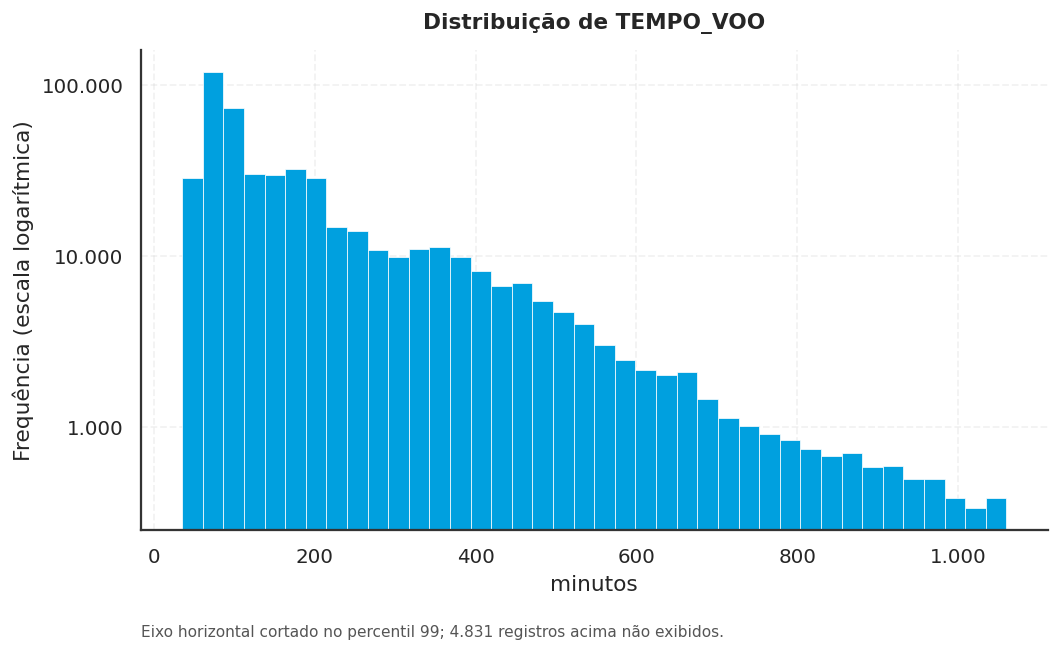

TEMPO_VOO: P99 = 1.060; acima do P99 = 4.831 registros
  abaixo de 250 minutos: 74,3%


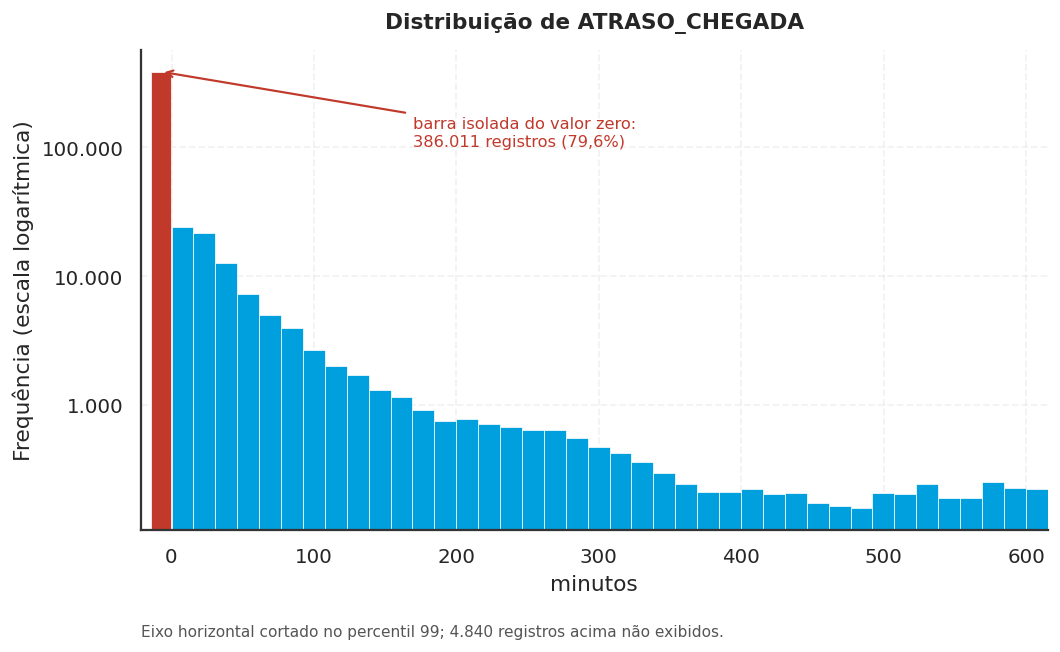

ATRASO_CHEGADA: P99 = 615; acima do P99 = 4.840 registros
  iguais a zero: 386.011 (79,6%)


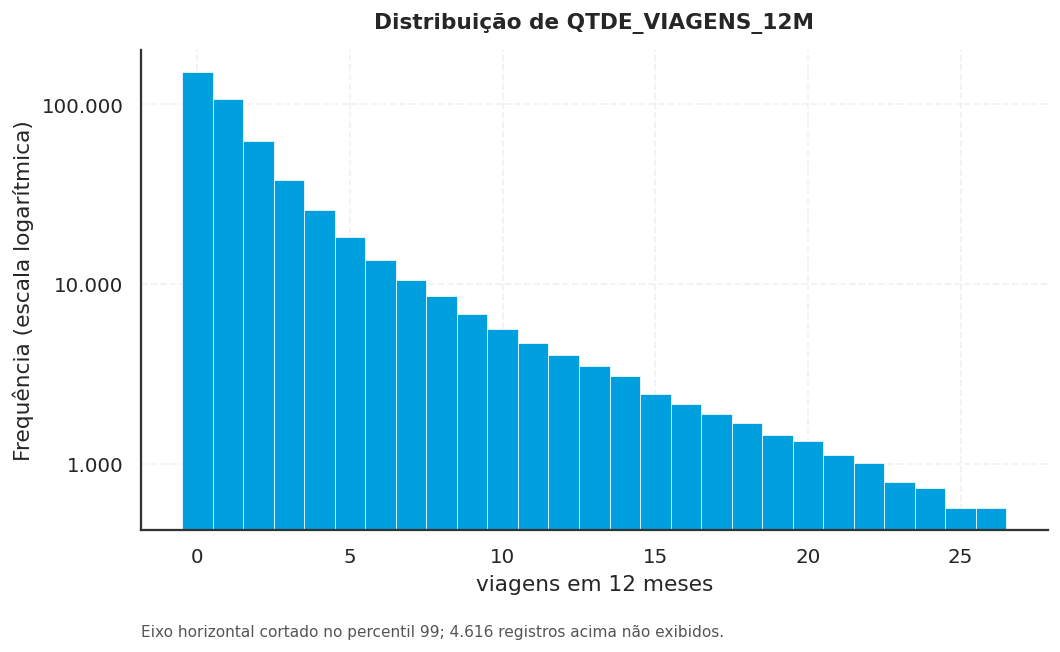

QTDE_VIAGENS_12M: P99 = 26; acima do P99 = 4.616 registros

Figuras gravadas em figuras/. Copie para assets/ preservando os nomes.

Assimetria: base completa x amostra do teste (n=2.000, random_state=42)
  TEMPO_VOO: base=3,68 | amostra=3,68
  ATRASO_CHEGADA: base=10,76 | amostra=10,77
  QTDE_VIAGENS_12M: base=4,12 | amostra=4,74


In [3]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

# O nbconvert executa com o diretorio do notebook como cwd, entao a raiz do
# projeto e localizada a partir de src/ em vez de assumida como o cwd.
RAIZ = next(p.parent for p in [Path('src'), Path('../src'), Path('/content/src')]
            if p.exists()).resolve()
sys.path.insert(0, str(RAIZ / 'src'))

from graficos import a1_histograma_normalidade, milhar, virgula

PASTA_FIGURAS = RAIZ / 'figuras'
PASTA_FIGURAS.mkdir(exist_ok=True)

# titulo, rotulo do eixo x, isolar o valor zero, usar intervalos inteiros
ESPECIFICACOES = {
    'TEMPO_VOO': ('Distribuição de TEMPO_VOO', 'minutos', False, False),
    'ATRASO_CHEGADA': ('Distribuição de ATRASO_CHEGADA', 'minutos', True, False),
    'QTDE_VIAGENS_12M': ('Distribuição de QTDE_VIAGENS_12M', 'viagens em 12 meses', False, True),
}

for coluna, (titulo, rotulo_x, isolar_zero, inteiros) in ESPECIFICACOES.items():
    serie = df[coluna].dropna()
    fig = a1_histograma_normalidade(serie, titulo, rotulo_x, isolar_zero, inteiros)
    fig.savefig(PASTA_FIGURAS / f'histograma_{coluna.lower()}.png')
    plt.show()

    # Numeros citados no texto das Figuras 7 a 9.
    p99 = serie.quantile(0.99)
    print(f'{coluna}: P99 = {milhar(p99)}; '
          f'acima do P99 = {milhar(int((serie > p99).sum()))} registros')
    if coluna == 'TEMPO_VOO':
        print(f'  abaixo de 250 minutos: {virgula((serie < 250).mean() * 100, 1, "%")}')
    if coluna == 'ATRASO_CHEGADA':
        print(f'  iguais a zero: {milhar(int((serie == 0).sum()))} '
              f'({virgula((serie == 0).mean() * 100, 1, "%")})')

print('\nFiguras gravadas em figuras/. Copie para assets/ preservando os nomes.')

# O item (d) afirma que as figuras, feitas sobre a base completa, sao compativeis
# com o teste do item (c), feito sobre a amostra de 2.000. A comparacao abaixo e a
# evidencia dessa afirmacao: a forma da amostra reproduz a da base.
print('\nAssimetria: base completa x amostra do teste (n=2.000, random_state=42)')
for coluna in ESPECIFICACOES:
    serie = df[coluna].dropna()
    amostra = serie.sample(n=2000, random_state=42)
    print(f'  {coluna}: base={virgula(serie.skew(), 2)} | '
          f'amostra={virgula(amostra.skew(), 2)}')


## 1. Constantes do conjunto completo (seção A.1.3)

As constantes vêm do conjunto completo, e não de uma amostra ou de um recorte de treino. De cada
variável são excluídos apenas os registros sem valor para aquela variável, o que explica a coluna
`n_valido`. O desvio reportado é o **populacional** (divisor N), que é o usado na padronização; o
amostral aparece ao lado só para mostrar que a diferença é desprezível neste volume.

In [4]:
constantes = pd.DataFrame([
    {
        'variavel': coluna,
        'n_valido': int(df[coluna].notna().sum()),
        'nulos': int(df[coluna].isna().sum()),
        'minimo': df[coluna].min(),
        'maximo': df[coluna].max(),
        'media': round(df[coluna].mean(), 4),
        'desvio_populacional': round(df[coluna].std(ddof=0), 4),
        'desvio_amostral': round(df[coluna].std(ddof=1), 4),
    }
    for coluna in VARIAVEIS
]).set_index('variavel')

constantes

,n_valido,nulos,minimo,maximo,media,desvio_populacional,desvio_amostral
variavel,,,,,,,
TEMPO_VOO,484675,240,35.0,4320.0,207.1565,208.2920,208.2922
ATRASO_CHEGADA,484915,0,0.0,4319.0,25.6551,136.4553,136.4555
QTDE_VIAGENS_12M,484760,155,0.0,107.0,3.1690,5.4124,5.4124


## 2. Diagnóstico da base analítica (seção A.1.3)

Os números que a seção A.1.3 usa para justificar o critério de limpeza e para afastar a suspeita de
que o truncamento contamine as constantes. A etapa anterior, de integração das quatro fontes, não é
refeita aqui: os 484.916 registros anteriores à deduplicação pertencem a `pre-processamento.ipynb`,
e o que esta seção faz é confirmar o resultado dela.

In [5]:
for coluna in VARIAVEIS:
    ausentes = int(df[coluna].isna().sum())
    print(
        f'{coluna:<18} {ausentes:>4} ausências  |  '
        f'{df[coluna].notna().mean() * 100:.2f}% de preenchimento  |  '
        f'{ausentes / len(df) * 100:.2f}% da base'
    )

print()
for coluna in VARIAVEIS:
    zeros = int((df[coluna] == 0).sum())
    print(f'{coluna:<18} {zeros:>7} zeros  ({zeros / len(df) * 100:.1f}% da base)')

# O unico negativo legitimo da base e' o -100 dos campos NPS_*, que faz parte da escala.
numericas = df.select_dtypes(include=[np.number]).columns
com_negativo = sorted(c for c in numericas if (df[c] < 0).any())
assert all(c.startswith('NPS_') for c in com_negativo), 'há valor negativo fora dos campos NPS_*'
print()
print(f'colunas numéricas com valor negativo: {len(com_negativo)}, todas do bloco NPS_*')

duplicado = df.loc[df['RESPONDENT_ID'] == 49088377, 'TEMPO_VOO']
assert len(duplicado) == 1
print(f'RESPONDENT_ID 49088377: 1 linha, TEMPO_VOO = {duplicado.iloc[0]:.0f} (média de 340 e 1.084)')

TEMPO_VOO           240 ausências  |  99.95% de preenchimento  |  0.05% da base
ATRASO_CHEGADA        0 ausências  |  100.00% de preenchimento  |  0.00% da base
QTDE_VIAGENS_12M    155 ausências  |  99.97% de preenchimento  |  0.03% da base

TEMPO_VOO                0 zeros  (0.0% da base)
ATRASO_CHEGADA      386011 zeros  (79.6% da base)
QTDE_VIAGENS_12M    152200 zeros  (31.4% da base)



colunas numéricas com valor negativo: 20, todas do bloco NPS_*
RESPONDENT_ID 49088377: 1 linha, TEMPO_VOO = 712 (média de 340 e 1.084)


O truncamento em si. A verificação abaixo mede quantos registros encostam no teto de 72 horas e
quanto as constantes de `TEMPO_VOO` mudariam se os valores mais altos fossem retirados. Se a
diferença fosse relevante, as constantes publicadas estariam medindo o limite do instrumento em vez
da distribuição.

In [6]:
TETOS = {'TEMPO_VOO': 4320, 'ATRASO_CHEGADA': 4319}
DOIS_DIAS = 2 * 24 * 60

for coluna, teto in TETOS.items():
    serie = df[coluna].dropna()
    print(
        f'{coluna:<18} {int((serie == teto).sum())} no teto de {teto}  |  '
        f'{int((serie >= 4000).sum()):>3} com 4.000 min ou mais  |  '
        f'{int((serie >= DOIS_DIAS).sum()):>3} com dois dias ou mais '
        f'({(serie >= DOIS_DIAS).sum() / len(df) * 100:.4f}% da base)'
    )

tempo_voo_todo = df['TEMPO_VOO'].dropna()
tempo_voo_sem_extremos = tempo_voo_todo[tempo_voo_todo < 4000]

print()
print(f'TEMPO_VOO completo ............ média {tempo_voo_todo.mean():.4f}  desvio {tempo_voo_todo.std(ddof=0):.4f}')
print(f'TEMPO_VOO sem 4.000 ou mais ... média {tempo_voo_sem_extremos.mean():.4f}  desvio {tempo_voo_sem_extremos.std(ddof=0):.4f}')
print(
    f'variação ...................... '
    f'{abs(tempo_voo_sem_extremos.mean() - tempo_voo_todo.mean()) / tempo_voo_todo.mean() * 100:.2f}% na média, '
    f'{abs(tempo_voo_sem_extremos.std(ddof=0) - tempo_voo_todo.std(ddof=0)) / tempo_voo_todo.std(ddof=0) * 100:.2f}% no desvio'
)

TEMPO_VOO          1 no teto de 4320  |    7 com 4.000 min ou mais  |   93 com dois dias ou mais (0.0192% da base)
ATRASO_CHEGADA     1 no teto de 4319  |   11 com 4.000 min ou mais  |   81 com dois dias ou mais (0.0167% da base)

TEMPO_VOO completo ............ média 207.1565  desvio 208.2920
TEMPO_VOO sem 4.000 ou mais ... média 207.0989  desvio 207.7408


variação ...................... 0.03% na média, 0.26% no desvio


## 3. Assimetria, percentil 95 e o teste do logaritmo (seções A.1.2 e A.1.4)

Origem dos dois números de assimetria citados no documento: o **3,68** de `TEMPO_VOO`, que aparece
no quadro da seção A.1.2, e o **0,69** obtido ao aplicar logaritmo nessa mesma variável, usado na
seção A.1.4 para dimensionar o que uma transformação de distribuição faria e a padronização não faz.

**Nota sobre o estimador.** `pandas.skew()` devolve a assimetria amostral corrigida, e não a
populacional, o que destoa do critério adotado para o desvio padrão, sempre calculado com divisor N.
A célula imprime as duas formas: com N desta ordem elas coincidem até a quarta casa decimal, de modo
que o 3,68 publicado não depende da escolha.

In [7]:
assimetria = pd.DataFrame(
    {
        'assimetria': [df[c].skew() for c in VARIAVEIS],
        'mediana': [df[c].median() for c in VARIAVEIS],
        'p95': [df[c].quantile(0.95) for c in VARIAVEIS],
        'razao_desvio_media': [df[c].std(ddof=0) / df[c].mean() for c in VARIAVEIS],
    },
    index=VARIAVEIS,
).round(4)

tempo_voo = df['TEMPO_VOO'].dropna()
assimetria_populacional = ((tempo_voo - tempo_voo.mean()) ** 3).mean() / tempo_voo.std(ddof=0) ** 3

print(f'assimetria de TEMPO_VOO, amostral corrigida .... {tempo_voo.skew():.4f}')
print(f'assimetria de TEMPO_VOO, populacional .......... {assimetria_populacional:.4f}')
print(f'assimetria de log(TEMPO_VOO) ................... {np.log(tempo_voo).skew():.4f}')

assimetria

assimetria de TEMPO_VOO, amostral corrigida .... 3.6829
assimetria de TEMPO_VOO, populacional .......... 3.6829
assimetria de log(TEMPO_VOO) ................... 0.6913


,assimetria,mediana,p95,razao_desvio_media
TEMPO_VOO,3.6829,130.0,575.0,1.0055
ATRASO_CHEGADA,10.7552,0.0,94.0,5.3188
QTDE_VIAGENS_12M,4.1238,1.0,13.0,1.7079


## 4. Constantes publicadas nas equações (seção A.1.4)

As equações do documento trazem as constantes arredondadas na quarta casa decimal. São elas, e não
as de precisão cheia, que ficam fixas no código: é o mesmo número que o leitor consegue substituir à
mão. A célula confere que o arredondamento não altera o resultado de forma perceptível.

In [8]:
MEDIA_TEMPO_VOO = 207.1565
DESVIO_TEMPO_VOO = 208.2920

MEDIA_ATRASO_CHEGADA = 25.6551
DESVIO_ATRASO_CHEGADA = 136.4553

MINIMO_QTDE_VIAGENS_12M = 0
MAXIMO_QTDE_VIAGENS_12M = 107

for coluna, media_publicada, desvio_publicado in [
    ('TEMPO_VOO', MEDIA_TEMPO_VOO, DESVIO_TEMPO_VOO),
    ('ATRASO_CHEGADA', MEDIA_ATRASO_CHEGADA, DESVIO_ATRASO_CHEGADA),
]:
    serie = df[coluna].dropna()
    com_precisao_cheia = (serie - serie.mean()) / serie.std(ddof=0)
    com_constante_publicada = (serie - media_publicada) / desvio_publicado
    diferenca = (com_precisao_cheia - com_constante_publicada).abs().max()
    print(f'{coluna}: diferença máxima entre as duas versões = {diferenca:.2e}')

TEMPO_VOO: diferença máxima entre as duas versões = 1.79e-06
ATRASO_CHEGADA: diferença máxima entre as duas versões = 1.08e-05


## 5. Aplicação da transformação

Cada variável recebe uma coluna escalonada nova e a coluna original permanece intacta.

**Registros sem valor.** A equação não é definida para ausência, então o nulo atravessa a
transformação e a coluna escalonada continua nula. Preencher com zero seria errado nos dois métodos:
na padronização o zero é a média da distribuição, e na normalização é o mínimo. A decisão sobre
imputar ou descartar esses registros pertence à preparação dos dados da seção 4.3, não ao
escalonamento.

In [9]:
ESCALONADAS = ['TEMPO_VOO_ESC', 'ATRASO_CHEGADA_ESC', 'QTDE_VIAGENS_12M_ESC']

df['TEMPO_VOO_ESC'] = (df['TEMPO_VOO'] - MEDIA_TEMPO_VOO) / DESVIO_TEMPO_VOO
df['ATRASO_CHEGADA_ESC'] = (df['ATRASO_CHEGADA'] - MEDIA_ATRASO_CHEGADA) / DESVIO_ATRASO_CHEGADA
df['QTDE_VIAGENS_12M_ESC'] = (
    (df['QTDE_VIAGENS_12M'] - MINIMO_QTDE_VIAGENS_12M)
    / (MAXIMO_QTDE_VIAGENS_12M - MINIMO_QTDE_VIAGENS_12M)
)

for original, escalonada in zip(VARIAVEIS, ESCALONADAS):
    print(
        f'{original:<18} {df[original].isna().sum():>4} nulos antes  |  '
        f'{df[escalonada].isna().sum():>4} nulos depois'
    )

TEMPO_VOO           240 nulos antes  |   240 nulos depois
ATRASO_CHEGADA        0 nulos antes  |     0 nulos depois
QTDE_VIAGENS_12M    155 nulos antes  |   155 nulos depois


## 6. Conferência manual entre a equação e a coluna gerada

A conferência usa três registros escolhidos por terem as três variáveis com valores não triviais.
Um registro em que a contagem de viagens ou o atraso valem zero não exercita a equação: `0 / 107`
devolve zero por construção e o atraso zero apenas testa o mínimo observado.

Cada registro é identificado pelo `RESPONDENT_ID`, chave de integração das quatro fontes e único na
base. Identificar por posição deixaria a tabela dependente da ordem em que `pre-processamento.ipynb`
concatena as fontes: uma mudança nessa ordem ou na regra de deduplicação invalidaria a conferência
sem que a comparação abaixo acusasse, já que ela confronta valores e não linhas. A seleção por chave
falha de forma explícita se o registro deixar de existir.

In [10]:
IDS_CONFERENCIA = [28211986, 28212172, 28213342]  # RESPONDENT_ID dos registros conferidos

selecao = df[df['RESPONDENT_ID'].isin(IDS_CONFERENCIA)]
assert len(selecao) == len(IDS_CONFERENCIA), 'RESPONDENT_ID da conferência não encontrado na base'

conferencia = selecao.set_index('RESPONDENT_ID').loc[IDS_CONFERENCIA, VARIAVEIS + ESCALONADAS].copy()

manual = pd.DataFrame({
    'TEMPO_VOO_ESC': (conferencia['TEMPO_VOO'] - 207.1565) / 208.2920,
    'ATRASO_CHEGADA_ESC': (conferencia['ATRASO_CHEGADA'] - 25.6551) / 136.4553,
    'QTDE_VIAGENS_12M_ESC': conferencia['QTDE_VIAGENS_12M'] / 107,
})

for coluna in ESCALONADAS:
    assert np.allclose(manual[coluna], conferencia[coluna]), coluna

print('A conferência manual reproduz a coluna gerada nos três registros.')

conferencia.round(4)

A conferência manual reproduz a coluna gerada nos três registros.


,TEMPO_VOO,ATRASO_CHEGADA,QTDE_VIAGENS_12M,TEMPO_VOO_ESC,ATRASO_CHEGADA_ESC,QTDE_VIAGENS_12M_ESC
RESPONDENT_ID,,,,,,
28211986,65.0,76,13.0,-0.6825,0.3689,0.1215
28212172,590.0,178,3.0,1.8380,1.1164,0.0280
28213342,140.0,11,45.0,-0.3224,-0.1074,0.4206


## 7. Valores fora do intervalo em dados futuros

As constantes são fixas, então um Cliente futuro com mais viagens que o máximo da base produz um
valor acima de 1. Nenhum truncamento é aplicado: cortar no teto faria Clientes diferentes receberem
o mesmo valor e quebraria a relação linear entre a variável e sua versão escalonada. O valor acima
de 1 é informação, e sinaliza que o teto observado na base foi ultrapassado.

Modelos que exijam entrada estritamente em [0, 1] precisam tratar isso na etapa de modelagem, e não
aqui.

In [11]:
futuros = pd.DataFrame({'QTDE_VIAGENS_12M': [0, 3, 13, 107, 120]})
futuros['QTDE_VIAGENS_12M_ESC'] = (
    (futuros['QTDE_VIAGENS_12M'] - MINIMO_QTDE_VIAGENS_12M)
    / (MAXIMO_QTDE_VIAGENS_12M - MINIMO_QTDE_VIAGENS_12M)
)

futuros.set_index('QTDE_VIAGENS_12M').round(4)

,QTDE_VIAGENS_12M_ESC
QTDE_VIAGENS_12M,
0,0.0000
3,0.0280
13,0.1215
107,1.0000
120,1.1215


## 8. Amplitude das três colunas escalonadas

As duas colunas padronizadas e a normalizada chegam ao modelo em faixas bem diferentes. A tabela
abaixo é a evidência quantitativa da ressalva registrada no fim da seção A.1.4.

Esta seção também reúne os números que a seção A.1.4 usa para dimensionar a compressão de
`QTDE_VIAGENS_12M`: a média da coluna escalonada, a fatia da base que cabe nos primeiros 3% do
intervalo e a distância, em desvios padrão, entre o máximo e a média da variável original.

In [12]:
amplitude = pd.DataFrame(
    {
        'minimo': [df[c].min() for c in ESCALONADAS],
        'maximo': [df[c].max() for c in ESCALONADAS],
        'media': [df[c].mean() for c in ESCALONADAS],
        'desvio_populacional': [df[c].std(ddof=0) for c in ESCALONADAS],
    },
    index=ESCALONADAS,
).round(4)

frequencia = df['QTDE_VIAGENS_12M_ESC'].dropna()
print(f'QTDE_VIAGENS_12M_ESC: {(frequencia <= 0.03).mean() * 100:.1f}% dos registros ficam em 0,03 ou abaixo')

frequencia_original = df['QTDE_VIAGENS_12M'].dropna()
distancia_do_maximo = (
    (frequencia_original.max() - frequencia_original.mean()) / frequencia_original.std(ddof=0)
)
print(
    f'QTDE_VIAGENS_12M: o máximo de {frequencia_original.max():.0f} viagens está a '
    f'{distancia_do_maximo:.2f} desvios padrão da média de {frequencia_original.mean():.4f}'
)

amplitude

QTDE_VIAGENS_12M_ESC: 74.3% dos registros ficam em 0,03 ou abaixo
QTDE_VIAGENS_12M: o máximo de 107 viagens está a 19.18 desvios padrão da média de 3.1690


,minimo,maximo,media,desvio_populacional
TEMPO_VOO_ESC,-0.8265,19.7456,-0.0000,1.0000
ATRASO_CHEGADA_ESC,-0.1880,31.4634,0.0000,1.0000
QTDE_VIAGENS_12M_ESC,0.0000,1.0000,0.0296,0.0506
